In [2]:
# Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Carga desde un archivo .csv sin indice
bl = pd.read_csv('Base_leads.csv') 

In [4]:
# Verificamos información del DataFrame
bl.info()

<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Fecha de Alta  210 non-null    str    
 1   Mes Lead       210 non-null    int64  
 2   AgLead         210 non-null    str    
 3   Titulo         210 non-null    str    
 4   Nombre         210 non-null    str    
 5   Telefono       0 non-null      float64
 6   Correo         0 non-null      float64
 7   Producto       196 non-null    str    
 8   Temperatura    210 non-null    str    
 9   Comentario     210 non-null    str    
 10  Asesor         210 non-null    str    
 11  Fuente         210 non-null    str    
 12  Origen         210 non-null    str    
 13                 210 non-null    str    
dtypes: float64(2), int64(1), str(11)
memory usage: 23.1 KB


In [5]:
# CORRECIONES DE LA BASE
bl = bl.drop(columns=["Telefono", "Correo"])
bl['Producto'] = bl['Producto'].fillna('Sin especificar')
bl = bl.rename(columns={' ': 'Estado'})


In [6]:
# Verificamos información del DataFrame tras la limpieza
bl.info()

<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Fecha de Alta  210 non-null    str  
 1   Mes Lead       210 non-null    int64
 2   AgLead         210 non-null    str  
 3   Titulo         210 non-null    str  
 4   Nombre         210 non-null    str  
 5   Producto       210 non-null    str  
 6   Temperatura    210 non-null    str  
 7   Comentario     210 non-null    str  
 8   Asesor         210 non-null    str  
 9   Fuente         210 non-null    str  
 10  Origen         210 non-null    str  
 11  Estado         210 non-null    str  
dtypes: int64(1), str(11)
memory usage: 19.8 KB


In [7]:
bl["Estado"].unique()

<StringArray>
['1 Ventas', 'Finalizado', 'Contactado']
Length: 3, dtype: str

In [8]:
bl['Estado'] = bl['Estado'].replace('1 Ventas', 'Ventas')


In [9]:
# Obtengo un análisis univariado de las variables categóricas - 1
Tabla_freq = bl['Estado'].value_counts().reset_index()
Tabla_freq

,Estado,count
0,Finalizado,123
1,Contactado,77
2,Ventas,10


In [10]:
# Ajusto el indice de mi dataframe
Tabla_freq_i= Tabla_freq.set_index('Estado')
Tabla_freq_i

,count
Estado,
Finalizado,123
Contactado,77
Ventas,10


<Axes: title={'center': 'Estatus de compra'}>

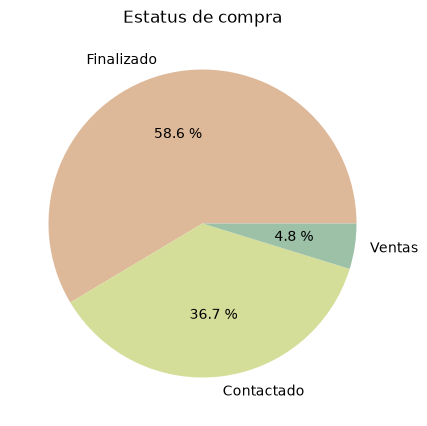

In [11]:
#Realizamos grafico de pastel del dataframe filtrado
mis_colores = ['#DEB999', '#D5DE99', '#9CC1A7']
Tabla_freq_i["count"].plot(kind='pie', figsize=(10,5), autopct="%0.1f %%", colors=mis_colores, title= "Estatus de compra")

In [12]:
# Obtengo un análisis univariado de las variables categóricas - 1
Tabla_freq1 = bl['Producto'].value_counts().reset_index()
Tabla_freq1

,Producto,count
0,EMZOOM,107
1,EMKOO,76
2,Sin especificar,14
3,GS8,7
4,GS4 MAX,2
5,No envian producto valido,2
6,GN8,1
7,AION,1


In [13]:
# Obtengo un filtro de los valores más reelevantes de la variable categórica seleccionada
Filtro = Tabla_freq1[(Tabla_freq1['Producto'] != 'Sin especificar') & (Tabla_freq1['Producto'] != 'No envian producto valido')]
Filtro

,Producto,count
0,EMZOOM,107
1,EMKOO,76
3,GS8,7
4,GS4 MAX,2
6,GN8,1
7,AION,1


In [14]:
# Ajusto el indice de mi dataframe
Filtro_i = Filtro.set_index('Producto')
Filtro_i

,count
Producto,
EMZOOM,107
EMKOO,76
GS8,7
GS4 MAX,2
GN8,1
AION,1


<Axes: title={'center': 'Productos más solicitados'}, xlabel='Producto'>

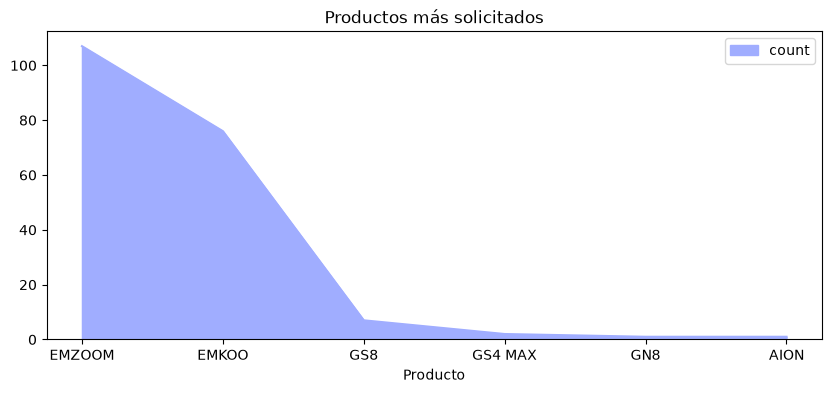

In [15]:
#Realizamos grafico de área del dataframe filtrado
Filtro_i.plot(kind='area', figsize=(10,4),alpha = 1, color="#A0ADFF", title="Productos más solicitados")

In [16]:
# Obtengo un análisis univariado de las variables categóricas - 1
Tabla_freq2 = bl['Temperatura'].value_counts().reset_index()
Tabla_freq2

,Temperatura,count
0,Lead Interes Medio,185
1,Lead Muy Interesado,21
2,Lead Interes Bajo,4


In [17]:
# Ajusto el indice de mi dataframe
Tabla_freq_i1= Tabla_freq2.set_index('Temperatura')
Tabla_freq_i1

,count
Temperatura,
Lead Interes Medio,185
Lead Muy Interesado,21
Lead Interes Bajo,4


<Axes: title={'center': 'Temperatura de leads'}>

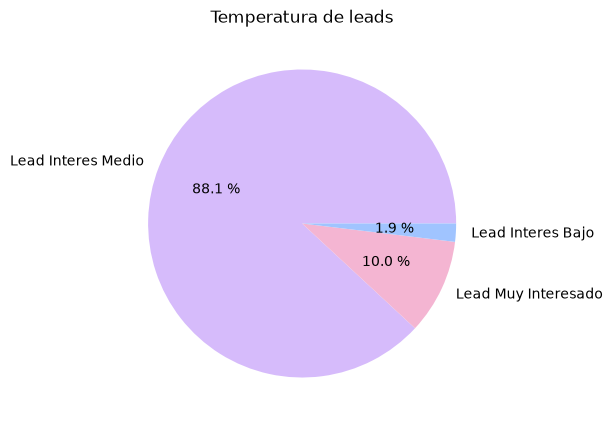

In [18]:
#Realizamos grafico de pastel del dataframe filtrado
mis_colores = ['#D6BBFB', '#F4B5D2', '#A0C4FF']
Tabla_freq_i1["count"].plot(kind='pie', figsize=(10,5), autopct="%0.1f %%", colors=mis_colores, title= "Temperatura de leads")